
# Assignment 5 — Exploring the Latent Space of a Pretrained StyleGAN2 Model

**Name:** Tejas Pebam  
**Topic:** Exploring the Latent Space of a Pretrained StyleGAN2 Model

### Objective
Use a pretrained StyleGAN2 generator to understand how changes in its latent space affect generated images. Two random latent vectors (`z1` and `z2`) are generated, their corresponding images are visualized, and a smooth interpolation is created between them. An additional experiment changes individual latent coordinates to observe their effect.




## 1. Install and verify required Python packages

In [2]:

# Install only packages that are missing.
# This cell is safe to run again.
import importlib.util
import subprocess
import sys


def install_if_missing(import_name, package_name=None):
    package_name = package_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", package_name
        ])


install_if_missing("torch")
install_if_missing("numpy")
install_if_missing("PIL", "pillow")
install_if_missing("matplotlib")
install_if_missing("requests")
install_if_missing("tqdm")
install_if_missing("ninja")

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No CUDA GPU detected. The notebook will use CPU; generation may be slower.")


Python: 3.12.10
PyTorch: 2.14.0+cpu
CUDA available: False
No CUDA GPU detected. The notebook will use CPU; generation may be slower.


## 2. Download the official StyleGAN2-ADA source and pretrained model

In [3]:

# Download everything using Python only.
# No Git executable and no wget executable are required.

import os
import shutil
import sys
import zipfile
from pathlib import Path

import requests

WORK_DIR = Path.cwd()
REPO_DIR = WORK_DIR / "repo_stylegan2"
REPO_ZIP = WORK_DIR / "stylegan2_ada_pytorch.zip"
EXTRACT_DIR = WORK_DIR / "_stylegan2_extract"
CHECKPOINT_PATH = REPO_DIR / "ffhq_256.pkl"

REPO_URL = "https://github.com/NVlabs/stylegan2-ada-pytorch/archive/refs/heads/main.zip"
# Official NVIDIA 256x256 FFHQ transfer-learning source network.
CHECKPOINT_URLS = [
    # Official NVIDIA 256x256 FFHQ transfer-learning source network.
    "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada/pretrained/"
    "transfer-learning-source-nets/ffhq-res256-mirror-paper256-noaug.pkl",
    # Official NVIDIA FFHQ pretrained network (1024x1024) as a fallback.
    "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada/pretrained/ffhq.pkl",
]


def download_file(url, destination):
    """Download a file with streaming and basic validation."""
    destination = Path(destination)
    temp_path = destination.with_suffix(destination.suffix + ".part")
    if temp_path.exists():
        temp_path.unlink()

    print(f"Downloading: {url}")
    headers = {"User-Agent": "Mozilla/5.0 StyleGAN2 Assignment"}

    with requests.get(url, headers=headers, stream=True, timeout=120) as response:
        response.raise_for_status()
        total = int(response.headers.get("content-length", 0))
        downloaded = 0
        next_report = 10

        with open(temp_path, "wb") as output_file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if not chunk:
                    continue
                output_file.write(chunk)
                downloaded += len(chunk)

                if total:
                    percent = downloaded * 100 // total
                    if percent >= next_report:
                        print(f"  {percent}% ({downloaded / 1024**2:.1f} MB)")
                        next_report += 10

    temp_path.replace(destination)
    print("Saved:", destination)


def valid_stylegan_checkpoint(path):
    """Return True only when the file looks like a real pickle checkpoint."""
    path = Path(path)
    if not path.is_file() or path.stat().st_size < 10_000_000:
        return False

    with open(path, "rb") as f:
        header = f.read(16)

    # Python pickle files normally start with 0x80 for the protocol versions
    # used by StyleGAN2 checkpoints. HTML/JSON error pages start differently.
    return bool(header) and header[0] == 0x80


# Remove an incomplete previous repository download.
if REPO_DIR.exists() and not (REPO_DIR / "legacy.py").is_file():
    shutil.rmtree(REPO_DIR)

# Download and extract the official repository when needed.
if not (REPO_DIR / "legacy.py").is_file():
    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)
    if REPO_ZIP.exists():
        REPO_ZIP.unlink()

    download_file(REPO_URL, REPO_ZIP)

    print("Extracting StyleGAN2-ADA...")
    with zipfile.ZipFile(REPO_ZIP, "r") as archive:
        archive.extractall(EXTRACT_DIR)

    source_roots = [p for p in EXTRACT_DIR.iterdir() if p.is_dir()]
    source_root = next(
        (p for p in source_roots if (p / "legacy.py").is_file()),
        None
    )

    if source_root is None:
        raise RuntimeError(
            "The StyleGAN2-ADA ZIP was downloaded, but legacy.py was not found. "
            "Please rerun this cell with an internet connection."
        )

    if REPO_DIR.exists():
        shutil.rmtree(REPO_DIR)
    shutil.move(str(source_root), str(REPO_DIR))
    shutil.rmtree(EXTRACT_DIR, ignore_errors=True)

print("StyleGAN2 source ready:", REPO_DIR)

# Remove a known-bad/incomplete checkpoint and download a fresh one.
if CHECKPOINT_PATH.exists() and not valid_stylegan_checkpoint(CHECKPOINT_PATH):
    print("Existing checkpoint is invalid or incomplete. Re-downloading it...")
    CHECKPOINT_PATH.unlink()

if not valid_stylegan_checkpoint(CHECKPOINT_PATH):
    download_error = None
    for checkpoint_url in CHECKPOINT_URLS:
        try:
            download_file(checkpoint_url, CHECKPOINT_PATH)
            if valid_stylegan_checkpoint(CHECKPOINT_PATH):
                print("Valid StyleGAN2 checkpoint found.")
                break
        except Exception as exc:
            download_error = exc
            if CHECKPOINT_PATH.exists():
                CHECKPOINT_PATH.unlink()
            print("Download attempt failed; trying the next official checkpoint URL...")
    else:
        raise RuntimeError(
            "Could not download a valid StyleGAN2 checkpoint. "
            "Check your internet connection and rerun Section 2."
        ) from download_error

if not valid_stylegan_checkpoint(CHECKPOINT_PATH):
    raise RuntimeError(
        "The downloaded file does not look like a valid StyleGAN2 pickle checkpoint. "
        "The server may have returned an error page. Delete the checkpoint and rerun this cell."
    )

print(f"Checkpoint verified: {CHECKPOINT_PATH.name}")
print(f"Checkpoint size: {CHECKPOINT_PATH.stat().st_size / (1024**2):.1f} MB")


StyleGAN2 source ready: c:\Users\Tejas Pebam\Downloads\repo_stylegan2
Downloading: https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada/pretrained/transfer-learning-source-nets/ffhq-res256-mirror-paper256-noaug.pkl
  10% (29.0 MB)
  20% (57.0 MB)
  30% (85.0 MB)
  40% (113.0 MB)
  50% (142.0 MB)
  60% (170.0 MB)
  70% (198.0 MB)
  80% (226.0 MB)
  90% (254.0 MB)
  100% (282.1 MB)
Saved: c:\Users\Tejas Pebam\Downloads\repo_stylegan2\ffhq_256.pkl
Valid StyleGAN2 checkpoint found.
Checkpoint verified: ffhq_256.pkl
Checkpoint size: 282.1 MB


## 3. Load the pretrained StyleGAN2 generator

In [4]:

import sys
import pickle
import torch

repo_path = str(REPO_DIR)
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

import legacy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    with open(CHECKPOINT_PATH, "rb") as f:
        network_bundle = legacy.load_network_pkl(f)
except (pickle.UnpicklingError, EOFError, ValueError) as exc:
    raise RuntimeError(
        "The pretrained checkpoint could not be read. "
        "Delete the file 'ffhq_256.pkl' and rerun Section 2 so it can be downloaded again."
    ) from exc

if "G_ema" not in network_bundle:
    raise RuntimeError("The checkpoint does not contain the expected 'G_ema' generator.")

generator = network_bundle["G_ema"].to(device)
generator.eval()
generator.requires_grad_(False)

latent_size = int(generator.z_dim)
label_size = int(generator.c_dim)
image_resolution = int(generator.img_resolution)

print(
    f"Generator loaded successfully | latent size = {latent_size} | "
    f"conditioning labels = {label_size} | resolution = {image_resolution}x{image_resolution} | "
    f"device = {device}"
)


Generator loaded successfully | latent size = 512 | conditioning labels = 0 | resolution = 256x256 | device = cpu


## 4. Create a helper function for generating images from latent vectors

In [5]:

def generate_images(latent_vectors, truncation_psi=0.7):
    """Generate RGB uint8 images from a batch of z-space latent vectors."""
    if latent_vectors.ndim != 2 or latent_vectors.shape[1] != latent_size:
        raise ValueError(
            f"Expected latent vectors of shape (batch, {latent_size}), "
            f"but received {tuple(latent_vectors.shape)}."
        )

    with torch.no_grad():
        labels = torch.zeros(
            (latent_vectors.shape[0], label_size),
            device=device
        )

        generated = generator(
            latent_vectors,
            labels,
            truncation_psi=truncation_psi,
            noise_mode="const",
            force_fp32=True,
        )

        generated = (generated.clamp(-1, 1) + 1) * 127.5
        generated = (
            generated
            .permute(0, 2, 3, 1)
            .to(torch.uint8)
            .cpu()
            .numpy()
        )

    return generated


# Small sanity check for the helper function shape logic.
print("Image helper is ready. Expected latent width:", latent_size)


Image helper is ready. Expected latent width: 512


## 5. Generate two randomly selected latent vectors, `z1` and `z2`

In [6]:

# Reproducible random latent vectors.
rng_seed = 314

torch.manual_seed(rng_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(rng_seed)

z1 = torch.randn((1, latent_size), device=device)
z2 = torch.randn((1, latent_size), device=device)

print("z1 first 5 values:", z1[0, :5].detach().cpu().numpy())
print("z2 first 5 values:", z2[0, :5].detach().cpu().numpy())


z1 first 5 values: [ 1.5926292  -1.3315034   0.4835573  -0.86249846 -1.2041903 ]
z2 first 5 values: [ 0.40149552  0.28586158 -1.1468486   1.92062     0.09759093]


## 6. Generate and compare the two images

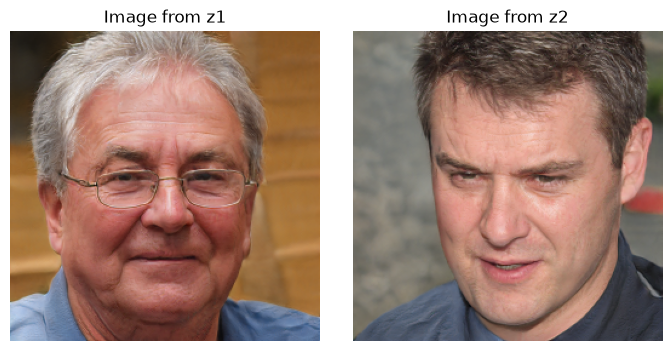

In [7]:

image_pair = generate_images(torch.cat([z1, z2], dim=0))
image_1 = image_pair[0]
image_2 = image_pair[1]

fig, panel = plt.subplots(1, 2, figsize=(7, 3.5))
panel[0].imshow(image_1)
panel[0].set_title("Image from z1")
panel[0].axis("off")

panel[1].imshow(image_2)
panel[1].set_title("Image from z2")
panel[1].axis("off")

plt.tight_layout()
plt.show()


## 7. Save the two generated images

In [8]:

Image.fromarray(image_1).save(WORK_DIR / "image_z1.png")
Image.fromarray(image_2).save(WORK_DIR / "image_z2.png")

print("Saved image_z1.png and image_z2.png")


Saved image_z1.png and image_z2.png


## 8. Create a smooth interpolation between `z1` and `z2`

In [9]:

def interpolate_latents(start, end, n_points=10):
    """Create evenly spaced latent vectors between two endpoints."""
    if start.shape != end.shape:
        raise ValueError("The two endpoint latent vectors must have the same shape.")
    if n_points < 2:
        raise ValueError("n_points must be at least 2.")

    t_values = torch.linspace(0.0, 1.0, n_points, device=start.device)
    t_values_2d = t_values[:, None]
    latent_path = start * (1.0 - t_values_2d) + end * t_values_2d
    return latent_path, t_values


latent_path, t_values = interpolate_latents(z1, z2, n_points=10)

print(
    f"Created {latent_path.shape[0]} interpolation points "
    f"from t={t_values[0].item():.2f} to t={t_values[-1].item():.2f}"
)


Created 10 interpolation points from t=0.00 to t=1.00


## 9. Generate an image at every interpolation point

In [10]:

interpolated_images = generate_images(latent_path)
print("Generated", len(interpolated_images), "images along the latent-space path")


Generated 10 images along the latent-space path


## 10. Visualize the complete interpolation sequence

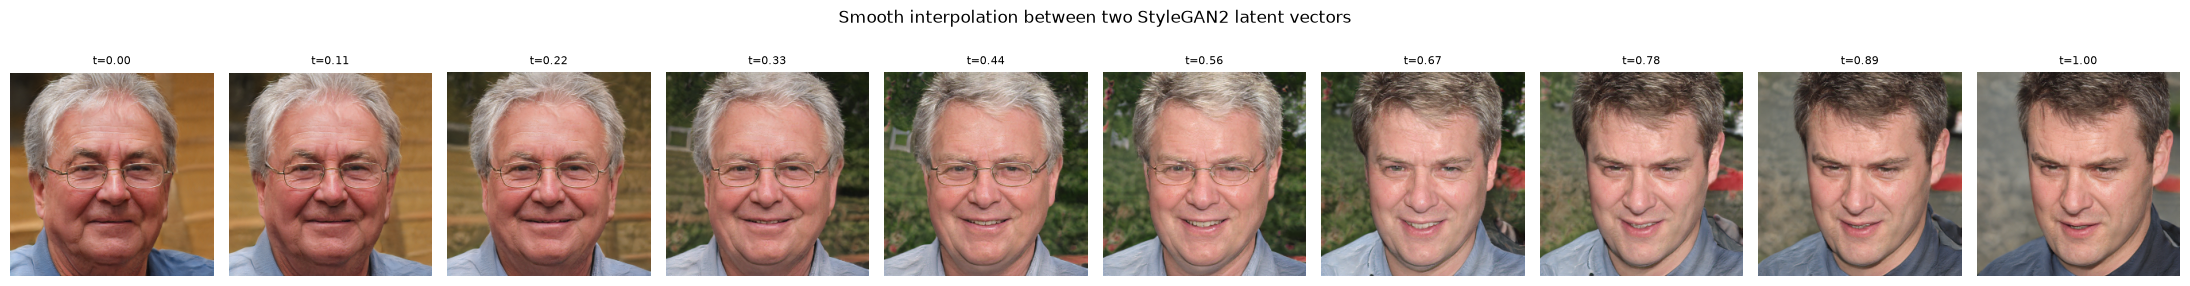

In [11]:

fig, axes = plt.subplots(1, len(interpolated_images), figsize=(22, 2.7))

for index, frame in enumerate(interpolated_images):
    axes[index].imshow(frame)
    axes[index].axis("off")
    axes[index].set_title(f"t={t_values[index].item():.2f}", fontsize=8)

plt.suptitle(
    "Smooth interpolation between two StyleGAN2 latent vectors",
    y=1.05
)
plt.tight_layout()
plt.savefig(WORK_DIR / "latent_space_interpolation.png", bbox_inches="tight", dpi=130)
plt.show()


## 11. Create a GIF showing the latent-space transition

In [12]:

gif_frames = [Image.fromarray(frame) for frame in interpolated_images]
gif_frames_full = gif_frames + gif_frames[::-1]

gif_frames_full[0].save(
    WORK_DIR / "latent_space_interpolation.gif",
    save_all=True,
    append_images=gif_frames_full[1:],
    duration=100,
    loop=0,
)

print(
    "Saved latent_space_interpolation.gif with",
    len(gif_frames_full),
    "frames"
)


Saved latent_space_interpolation.gif with 20 frames



## 12. Explore the effect of changing individual latent coordinates

A single latent vector is kept fixed while one coordinate is changed at a time. This helps show that different coordinate values can change the appearance of the generated face, while one raw coordinate does not necessarily correspond to one isolated human-readable feature.


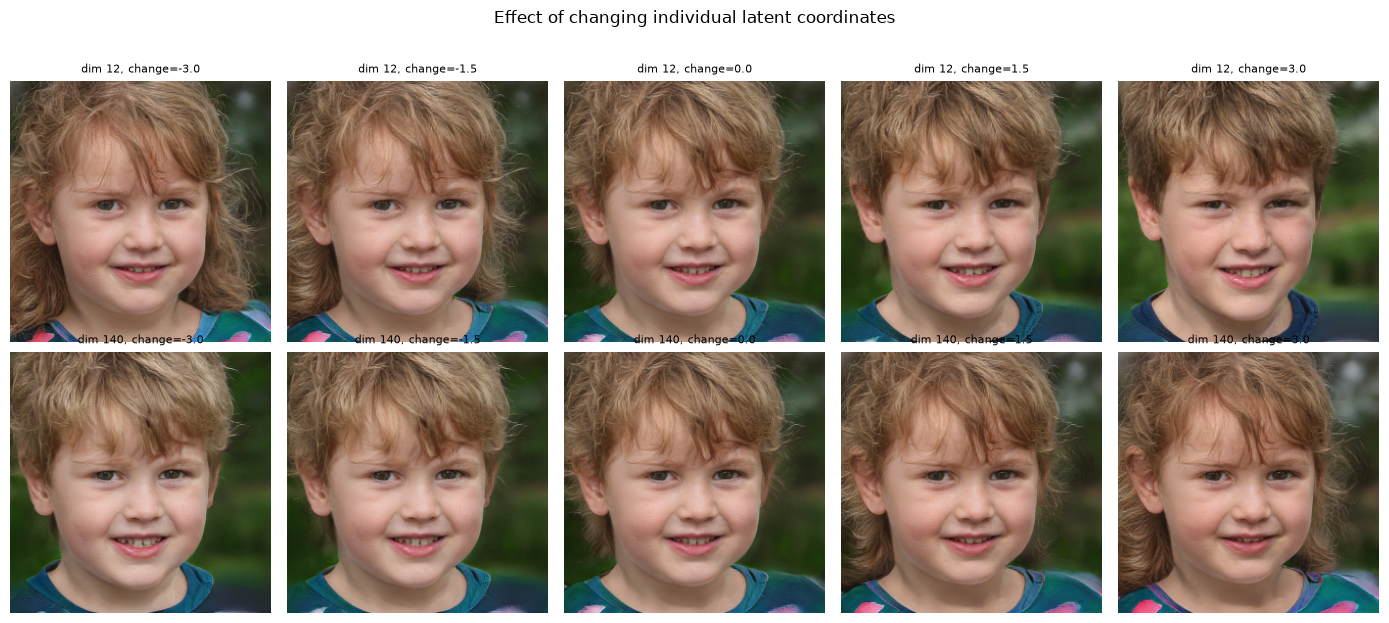

In [13]:

# Keep one latent vector fixed and change selected coordinates.
torch.manual_seed(2718)
base_latent = torch.randn((1, latent_size), device=device)

coordinates_to_test = [12, 140]
change_values = [-3.0, -1.5, 0.0, 1.5, 3.0]

for coordinate in coordinates_to_test:
    if coordinate < 0 or coordinate >= latent_size:
        raise IndexError(
            f"Coordinate {coordinate} is outside the latent range 0 to {latent_size - 1}."
        )

coordinate_results = []

for coordinate in coordinates_to_test:
    modified_latents = []

    for change in change_values:
        modified = base_latent.clone()
        modified[0, coordinate] += change
        modified_latents.append(modified)

    modified_batch = torch.cat(modified_latents, dim=0)
    coordinate_results.append(generate_images(modified_batch))

fig, axes = plt.subplots(
    len(coordinates_to_test),
    len(change_values),
    figsize=(14, 6)
)

for row_index, coordinate in enumerate(coordinates_to_test):
    for column_index, change in enumerate(change_values):
        axes[row_index][column_index].imshow(
            coordinate_results[row_index][column_index]
        )
        axes[row_index][column_index].axis("off")
        axes[row_index][column_index].set_title(
            f"dim {coordinate}, change={change}", fontsize=8
        )

plt.suptitle("Effect of changing individual latent coordinates", y=1.03)
plt.tight_layout()
plt.savefig(WORK_DIR / "latent_coordinate_experiment.png", bbox_inches="tight", dpi=130)
plt.show()



## Written Observations

**Observation from the two random latent vectors.**  
The two randomly selected latent vectors, `z1` and `z2`, produce different generated face images. This shows that different points in the latent space can correspond to different image appearances.

**Observation during interpolation.**  
When the latent vector moves gradually from `z1` to `z2`, the generated image also changes gradually. The intermediate images form a smooth visual transition between the two endpoint images.

**What the latent space represents.**  
The latent vector is a numerical input to the pretrained generator. Moving to different positions in latent space changes the visual output produced by the model.

**Observation from individual latent coordinates.**  
Changing one coordinate while keeping the remaining coordinates fixed can change the generated image. A single raw coordinate does not necessarily represent one isolated facial feature; several visual properties can change together.

**Conclusion.**  
This experiment demonstrates how a pretrained StyleGAN2 model can generate face images from latent vectors and how moving through its latent space can produce smooth changes in the generated images.
